# One dimensional dummy problem

In this section the goal will be to solve the 1 dimensional dummy problem for a first step to pressure gradients

\begin{equation}
\begin{aligned}
\rho \partial_t v &=-RT\partial_x\rho-\rho v \partial_x v+\mu\partial_x^2 v -S\\
\partial_t\rho&=-(\partial_x \rho)v-\rho (\partial_x v)
\end{aligned}
\end{equation}

Where

\begin{equation}
S = \frac{\mu}{K}v
\end{equation}

under IC:

\begin{equation}
\left\{ \begin{aligned}
\rho(x,0) &= 1 \\
v(x,0) &= 0
\end{aligned}\right.
\end{equation}

and BC:
\begin{equation}
\left\{\begin{aligned}
\rho(0,t) &= 2-e^{-10t} \\
\partial_x v(0,t) &= 0 \\
v(L,t) &= 0
\end{aligned}\right.
\end{equation}

In [1]:
using OrdinaryDiffEq, MethodOfLines, DomainSets, ModelingToolkit;

## Definitions

In [2]:
# Parameters, variables, and derivatives
@parameters t x
@variables ρ(..) v(..)

# definitions of derivatives
Dt = Differential(t)
Dx = Differential(x)
Dxx = Differential(x)^2

# constants
R = 1.0
T = 1.0
μ = 1.0
K = 1.0

# PDE
eq = [
    Dt(v(t, x)) ~ (-R*T*Dx(ρ(t, x))+μ*Dxx(v(t, x))-ρ(t, x)*v(t, x)*Dx(v(t, x))-v(t, x)*μ/K)/ρ(t, x),
    Dt(ρ(t, x)) ~ -Dx(ρ(t, x))*v(t, x)-ρ(t, x)*Dx(v(t, x))
]

# Boundary conditions
bcs = [
    ρ(0, x) ~ 1.0,
    v(0, x) ~ 0.0,
    ρ(t,0) ~ 2.0 -exp(-10.0*t),
    Dx(v(t, 0)) ~ 0.0,
    v(t, 1) ~ 0.0
]

# Space and time domains
domains = [
    t ∈ Interval(0.0, 8.0),
    x ∈ Interval(0.0, 1.0)
]

2-element Vector{Symbolics.VarDomainPairing}:
 Symbolics.VarDomainPairing(t, 0.0 .. 8.0)
 Symbolics.VarDomainPairing(x, 0.0 .. 1.0)

## PDE

In [3]:
# PDE system
@named pdesys = PDESystem(
    eq, 
    bcs, 
    domains, 
    [t, x], [ρ(t, x), v(t, x)]
)

PDESystem
Equations: Equation[Differential(t, 1)(v(t, x)) ~ (Differential(x, 2)(v(t, x)) - Differential(x, 1)(ρ(t, x)) - v(t, x) - ρ(t, x)*v(t, x)*Differential(x, 1)(v(t, x))) / ρ(t, x), Differential(t, 1)(ρ(t, x)) ~ -ρ(t, x)*Differential(x, 1)(v(t, x)) - Differential(x, 1)(ρ(t, x))*v(t, x)]
Boundary Conditions: Equation[ρ(0, x) ~ 1.0, v(0, x) ~ 0.0, ρ(t, 0) ~ 2.0 - exp(-10.0t), Differential(x, 1)(v(t, 0)) ~ 0.0, v(t, 1) ~ 0.0]
Domain: Symbolics.VarDomainPairing[Symbolics.VarDomainPairing(t, 0.0 .. 8.0), Symbolics.VarDomainPairing(x, 0.0 .. 1.0)]
Dependent Variables: Num[ρ(t, x), v(t, x)]
Independent Variables: Num[t, x]
Parameters: SciMLBase.NullParameters()
Default Parameter ValuesModelingToolkitBase.AtomicArrayDict{SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{SymReal}, Dict{SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{SymReal}, SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{SymReal}}}()

In [ ]:
# Method of lines discretization
dx = .02
order = 3

MOL_scheme = UpwindScheme(approx_order = order)
discretization = MOLFiniteDifference([x => dx], t, advection_scheme = MOL_scheme)

# Convert the PDE problem into an ODE problem
prob = discretize(pdesys, discretization);

# Solver

In [11]:
using OrdinaryDiffEq

In [12]:
# Solve ODE problem
sol = solve(prob, Tsit5(), saveat = 0.1)

LoadError: This solver is not able to use mass matrices. For compatible solvers see https://docs.sciml.ai/DiffEqDocs/stable/solvers/dae_solve/

## Plotting/animating

In [ ]:
# Plot results and compare with exact solution
discrete_x = sol[x];
discrete_t = sol[t];
sol_ρ = sol[ρ(t, x)];
sol_v = sol[v(t, x)];


folder = "e. one dimensional poreus";
mkpath(folder);

In [13]:
# Used for plotting
using Plots

In [14]:
# limits
ρmin = minimum(sol_ρ)
ρmax = maximum(sol_ρ)

vmin = minimum(sol_v)
vmax = maximum(sol_v)

left_min = ρmin
left_max = ρmax

anim = @animate for k in 1:length(discrete_t)

    # top plot: density + total pressure
    p1 = plot(
        discrete_x,
        sol_ρ[k, :],
        label = "density",
        color = :blue,
        xlabel = "x",
        ylabel = "density",
        title = "t = $(round(discrete_t[k], digits=3))",
        ylims = (0, 4),
        legend = :topright
    )

    # bottom plot: velocity
    p2 = plot(
        discrete_x,
        sol_v[k, :],
        label = "velocity",
        color = :green,
        xlabel = "x",
        ylabel = "velocity",
        ylims = (vmin, vmax),
        legend = :topright
    )

    # combine
    plot(
        p1,
        p2,
        layout = (2,1),
        size = (800,600)
    )

end

Animation("C:\\Users\\noudh\\AppData\\Local\\Temp\\jl_maj8Z3", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000020.png", "000021.png", "000022.png", "000023.png", "000024.png", "000025.png", "000026.png", "000027.png", "000028.png", "000029.png"])

[ Info: Saved animation to c:\Users\noudh\uni\MEP\3. method of lines\e. one dimensional poreus\weno.gif


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\3. method of lines\\e. one dimensional poreus\\weno.gif")
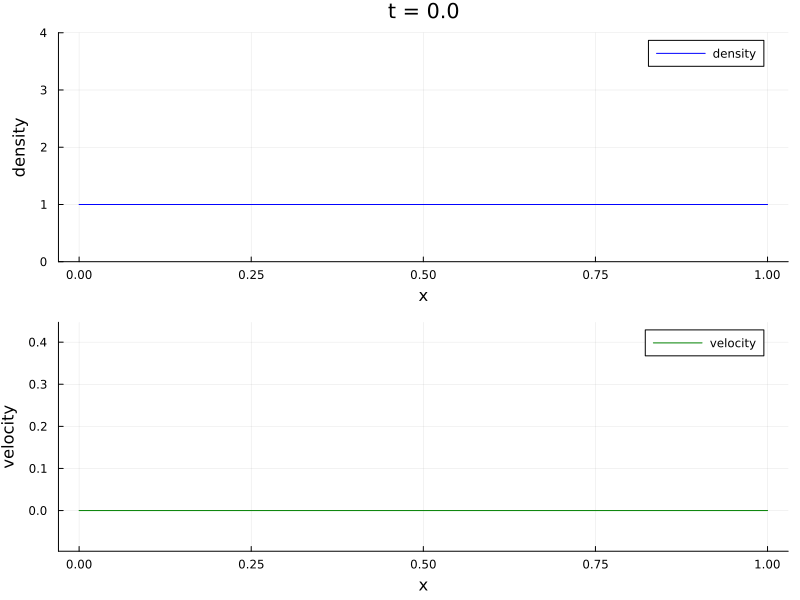

In [15]:
gif(anim, joinpath(folder, "weno.gif"), fps = 10)

# Debugging

In [ ]:
# debugging
sol.retcode
length(sol.t)
sol.t[end]
minimum(sol_ρ)

1.0

In [ ]:
# debugging
sol.stats

SciMLBase.DEStats
Number of function 1 evaluations:                  74283
Number of function 2 evaluations:                  0
Number of W matrix evaluations:                    0
Number of linear solves:                           0
Number of Jacobians created:                       0
Number of nonlinear solver iterations:             0
Number of nonlinear solver convergence failures:   0
Number of fixed-point solver iterations:           0
Number of fixed-point solver convergence failures: 0
Number of rootfind condition calls:                0
Number of accepted steps:                          12379
Number of rejected steps:                          1